In [68]:
import os
print(os.listdir('/data'))

['1AKE.cif', '1XI4.cif', '1Y64.cif', '1E4K.cif', '1FYT.cif']


In [69]:
!pip install biopython matplotlib numpy -q

In [70]:
import Bio
print(Bio.__version__)

1.88


Извлекаем данные по id.

In [71]:
import os
from Bio.PDB import MMCIFParser

DATA_DIR = '/data'

def load_structure(pdb_id, data_dir=DATA_DIR):
    path = os.path.join(data_dir, f"{pdb_id}.cif")

    if not os.path.exists(path):
        available = [f for f in os.listdir(data_dir) if f.endswith('.cif')]
        raise FileNotFoundError(
            f"{pdb_id}.cif не найден в {data_dir}. "
            f"Доступные .cif: {available}"
        )

    parser = MMCIFParser(QUIET=True) # QUIET — если True, подавляет предупреждения при построении модели
    structure = parser.get_structure(pdb_id, path)

    n_chains = len(list(structure.get_chains()))
    n_atoms = len(list(structure.get_atoms()))
    print(f"\n{pdb_id}: {n_chains} цепей, {n_atoms} атомов")
    return structure

In [72]:
PDB_IDS = ['1FYT', '1AKE', '1XI4', '1E4K', '1Y64']

for pdb_id in PDB_IDS:
    s = load_structure(pdb_id)
    for chain in s[0]:
        n_res = len([r for r in chain if r.id[0] == ' '])
        if n_res > 0:
              print(f"   цепь {chain.id}: {n_res} остатков")


1FYT: 5 цепей, 6644 атомов
   цепь A: 180 остатков
   цепь B: 179 остатков
   цепь C: 13 остатков
   цепь D: 198 остатков
   цепь E: 240 остатков

1AKE: 2 цепей, 3804 атомов
   цепь A: 214 остатков
   цепь B: 214 остатков

1XI4: 18 цепей, 15300 атомов
   цепь A: 1630 остатков
   цепь B: 1630 остатков
   цепь C: 1630 остатков
   цепь J: 70 остатков
   цепь K: 70 остатков
   цепь L: 70 остатков
   цепь D: 1630 остатков
   цепь E: 1630 остатков
   цепь F: 1630 остатков
   цепь M: 70 остатков
   цепь N: 70 остатков
   цепь O: 70 остатков
   цепь G: 1630 остатков
   цепь H: 1630 остатков
   цепь I: 1630 остатков
   цепь P: 70 остатков
   цепь Q: 70 остатков
   цепь R: 70 остатков

1E4K: 5 цепей, 5042 атомов
   цепь A: 216 остатков
   цепь B: 216 остатков
   цепь C: 172 остатков

1Y64: 2 цепей, 6162 атомов
   цепь A: 356 остатков
   цепь B: 411 остатков


Ищем все пары атомов из разных цепей, которые находятся в радиусе 5.0 (без атомов водорода).

In [73]:
from Bio.PDB import NeighborSearch

def find_interchain_contacts(structure, cutoff=5.0):
    atoms = [a for a in structure.get_atoms() if a.element != 'H']
    ns = NeighborSearch(atoms)
    pairs = ns.search_all(cutoff, level='A') # параметр level позволяет возвращать объекты нужного уровня, здесь - атомы

    interchain = []
    for a1, a2 in pairs:
        c1 = a1.get_parent().get_parent().id  # chain id
        c2 = a2.get_parent().get_parent().id
        if c1 != c2:
            interchain.append((a1, a2))
    return interchain

In [74]:
for pdb_id in PDB_IDS:
    s = load_structure(pdb_id)
    contacts = find_interchain_contacts(s, cutoff=5.0)
    print(f"{pdb_id}: {len(contacts)} межцепочечных контактов\n")


1FYT: 5 цепей, 6644 атомов
1FYT: 4271 межцепочечных контактов


1AKE: 2 цепей, 3804 атомов
1AKE: 230 межцепочечных контактов


1XI4: 18 цепей, 15300 атомов
1XI4: 115 межцепочечных контактов


1E4K: 5 цепей, 5042 атомов
1E4K: 1899 межцепочечных контактов


1Y64: 2 цепей, 6162 атомов
1Y64: 468 межцепочечных контактов



Строим бинарную матрицу контактов между остатками двух цепей.

In [75]:
import numpy as np
from Bio.PDB import NeighborSearch

def build_contact_map(structure, chain1_id, chain2_id, cutoff=5.0):
    model = structure[0]
    residues1 = [r for r in model[chain1_id] if r.id[0] == ' ']
    residues2 = [r for r in model[chain2_id] if r.id[0] == ' ']

    contact_map = np.zeros((len(residues1), len(residues2)), dtype=int)

    atoms1 = [] # список всех атомов первой цепи (кроме H)
    res1_idx = {} # словарь (атом → индекс его остатка в residues1)
    for i, r in enumerate(residues1):
        for a in r:
            if a.element != 'H':
                atoms1.append(a)
                res1_idx[a] = i

    ns = NeighborSearch(atoms1)
    for j, res2 in enumerate(residues2):
        for atom2 in res2:
            if atom2.element == 'H':
                continue
            for atom1 in ns.search(atom2.coord, cutoff, level='A'):
                contact_map[res1_idx[atom1], j] = 1

    return contact_map, residues1, residues2

Визуализация контактов:

In [76]:
import matplotlib.pyplot as plt
import numpy as np

def plot_contact_map(cmap, residues1, residues2,
                     chain1_id, chain2_id, pdb_id, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.imshow(cmap, cmap='Blues', aspect='auto', origin='lower',
              vmin=0, vmax=1, interpolation='nearest')

    # подписи осей с номерами остатков
    if residues1:
        ax.set_yticks([0, len(residues1) - 1])
        ax.set_yticklabels([residues1[0].id[1], residues1[-1].id[1]])
    if residues2:
        ax.set_xticks([0, len(residues2) - 1])
        ax.set_xticklabels([residues2[0].id[1], residues2[-1].id[1]])

    ax.set_xlabel(f'Остатки цепи {chain2_id}', fontsize=11)
    ax.set_ylabel(f'Остатки цепи {chain1_id}', fontsize=11)
    ax.set_title(f'{pdb_id}: контакты {chain1_id}–{chain2_id} (<5 Å)',
                 fontsize=12, fontweight='bold')

    # счётчик контактов
    n_pairs = int(cmap.sum())
    ax.text(0.98, 0.98, f'{n_pairs} пар остатков',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color='darkred',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.colorbar(ax.images[0], label='Контакт')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


1FYT: 5 цепей, 6644 атомов

1FYT: межцепочечных контактов 4271
  === D vs A ===
    карта (198, 180), пар остатков: 4


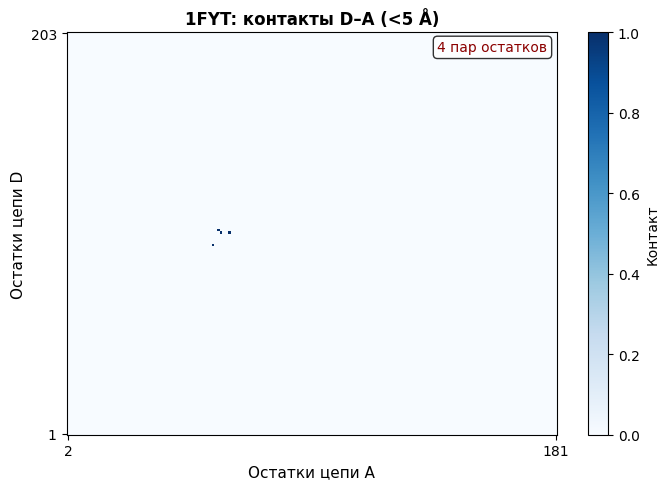

  === D vs E ===
    карта (198, 240), пар остатков: 152


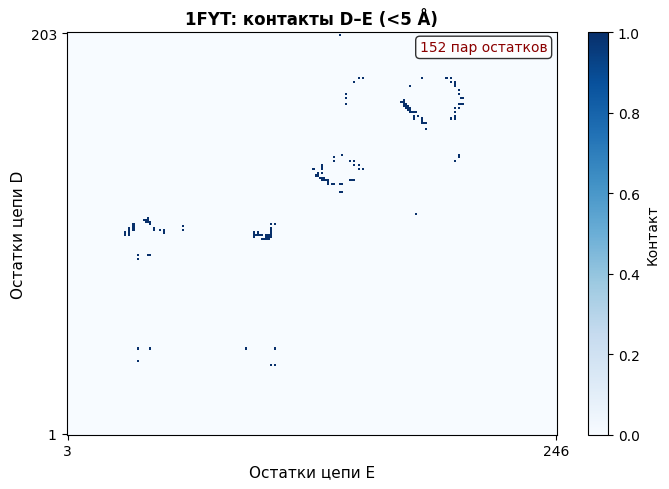


1AKE: 2 цепей, 3804 атомов

1AKE: межцепочечных контактов 230
  === A vs B ===
    карта (214, 214), пар остатков: 17


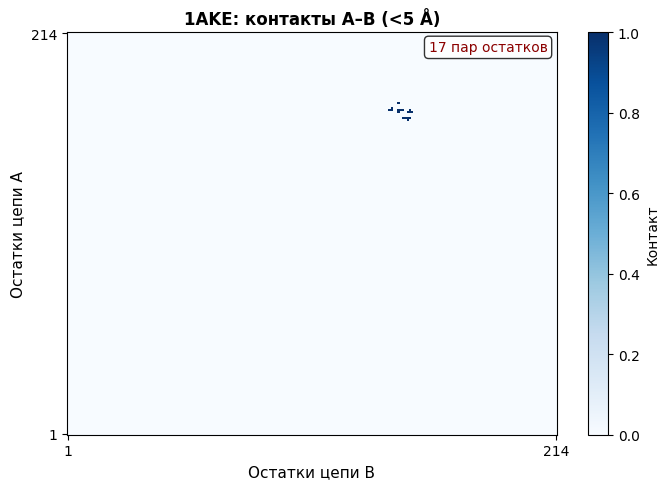


1XI4: 18 цепей, 15300 атомов

1XI4: межцепочечных контактов 115
  === A vs B ===
    карта (1630, 1630), пар остатков: 1


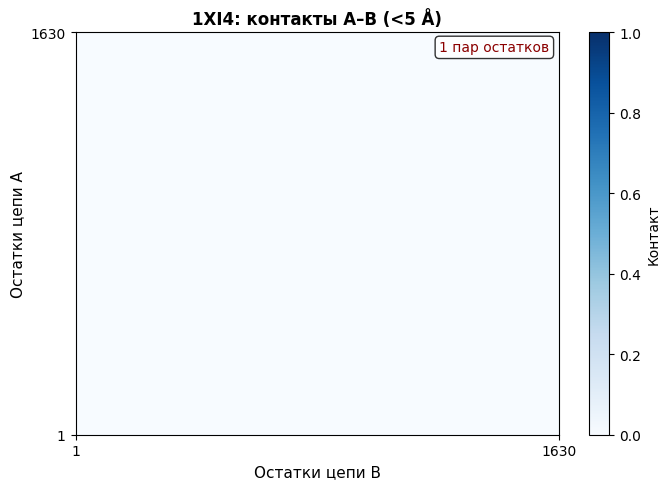


1E4K: 5 цепей, 5042 атомов

1E4K: межцепочечных контактов 1899
  === A vs B ===
    карта (216, 216), пар остатков: 90


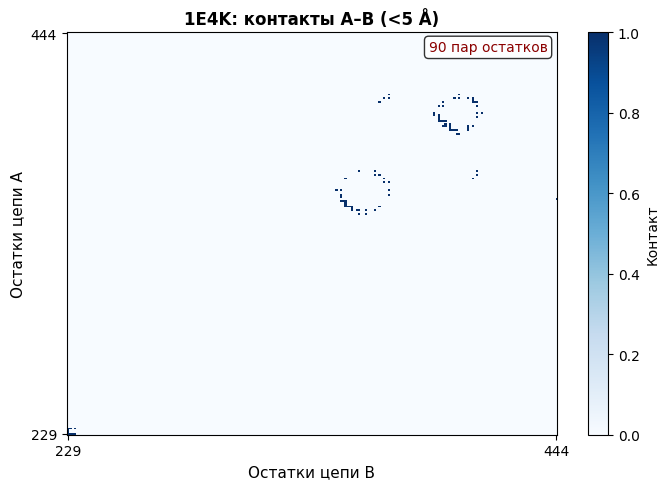


1Y64: 2 цепей, 6162 атомов

1Y64: межцепочечных контактов 468
  === A vs B ===
    карта (356, 411), пар остатков: 75


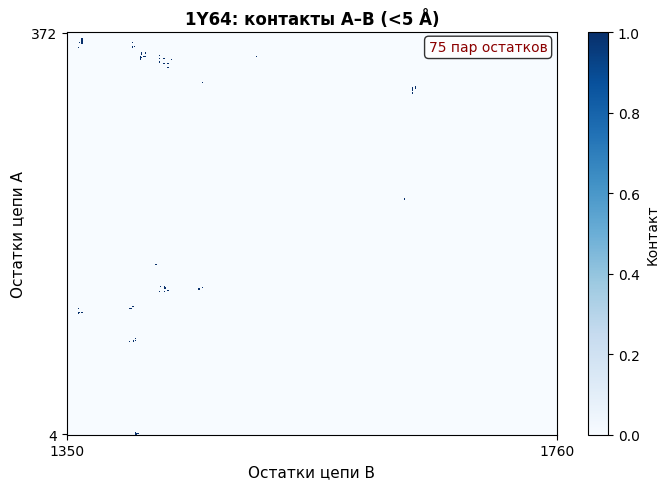

In [77]:
import os

TARGETS = {
    '1FYT': [('D', 'A'), ('D', 'E')],
    '1AKE': [('A', 'B')],
    '1XI4': [('A', 'B')],
    '1E4K': [('A', 'B')],
    '1Y64': [('A', 'B')],
}

os.makedirs('/content/results', exist_ok=True)

for pdb_id, pairs in TARGETS.items():
    s = load_structure(pdb_id)

    contacts = find_interchain_contacts(s, cutoff=5.0)
    print(f"\n{pdb_id}: межцепочечных контактов {len(contacts)}")

    for c1, c2 in pairs:
        print(f"  === {c1} vs {c2} ===")
        cmap, r1, r2 = build_contact_map(s, c1, c2, cutoff=5.0)
        print(f"    карта {cmap.shape}, пар остатков: {cmap.sum()}")

        plot_contact_map(cmap, r1, r2, c1, c2, pdb_id,
                         save_path=f'/content/results/{pdb_id}_{c1}{c2}_map.png')